In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
#read of dataphram
df=pd.read_csv('../../data/raw/dna-classification-dataset/synthetic_dna_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        3000 non-null   object 
 1   Sequence         3000 non-null   object 
 2   GC_Content       3000 non-null   float64
 3   AT_Content       3000 non-null   float64
 4   Sequence_Length  3000 non-null   int64  
 5   Num_A            3000 non-null   int64  
 6   Num_T            3000 non-null   int64  
 7   Num_C            3000 non-null   int64  
 8   Num_G            3000 non-null   int64  
 9   kmer_3_freq      3000 non-null   float64
 10  Mutation_Flag    3000 non-null   int64  
 11  Class_Label      3000 non-null   object 
 12  Disease_Risk     3000 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 304.8+ KB


In [3]:
#overview of data
def overview(df):
    '''
    Erstelle einen Überblick über einige Eigenschaften der Spalten eines DataFrames.
    VARs
        df: Der zu betrachtende DataFrame
    RETURNS:
        overview: Überblick über einige Eigenschaften der Spalten eines DataFrames.
    '''
    overview=display(pd.DataFrame({'dtype': df.dtypes,
                          'total': df.count(),
                          'missing values(n)': df.isna().sum(),
                          'missing values(%)': df.isna().mean()*100,
                          'number of uniques': df.nunique(),
                          'uniques': [df[col].unique() for col in df.columns]
                         }))
    return overview
    
overview(df)

,dtype,total,missing values(n),missing values(%),number of uniques,uniques
Sample_ID,object,3000,0,0.0,3000,"[SAMPLE_1, SAMPLE_2, SAMPLE_3, SAMPLE_4, SAMPL..."
Sequence,object,3000,0,0.0,3000,[CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCC...
GC_Content,float64,3000,0,0.0,33,"[50.0, 45.0, 51.0, 55.0, 46.0, 62.0, 42.0, 59...."
AT_Content,float64,3000,0,0.0,33,"[50.0, 55.0, 49.0, 45.0, 54.0, 38.0, 58.0, 41...."
Sequence_Length,int64,3000,0,0.0,1,[100]
Num_A,int64,3000,0,0.0,30,"[22, 27, 26, 28, 24, 29, 12, 32, 18, 30, 25, 2..."
Num_T,int64,3000,0,0.0,32,"[28, 23, 17, 30, 26, 33, 24, 25, 22, 16, 27, 2..."
Num_C,int64,3000,0,0.0,32,"[19, 22, 30, 23, 25, 26, 35, 31, 24, 29, 17, 2..."
Num_G,int64,3000,0,0.0,30,"[31, 23, 21, 32, 19, 27, 28, 18, 24, 26, 33, 2..."
kmer_3_freq,float64,3000,0,0.0,872,"[0.986, 0.486, 0.367, 0.404, 0.818, 0.495, 0.5..."


In [ ]:
#Missing values
print(df.isna().sum())

Sample_ID          0
Sequence           0
GC_Content         0
AT_Content         0
Sequence_Length    0
Num_A              0
Num_T              0
Num_C              0
Num_G              0
kmer_3_freq        0
Mutation_Flag      0
Class_Label        0
Disease_Risk       0
dtype: int64


In [5]:
#search for duplicates
df.duplicated().sum()

np.int64(0)

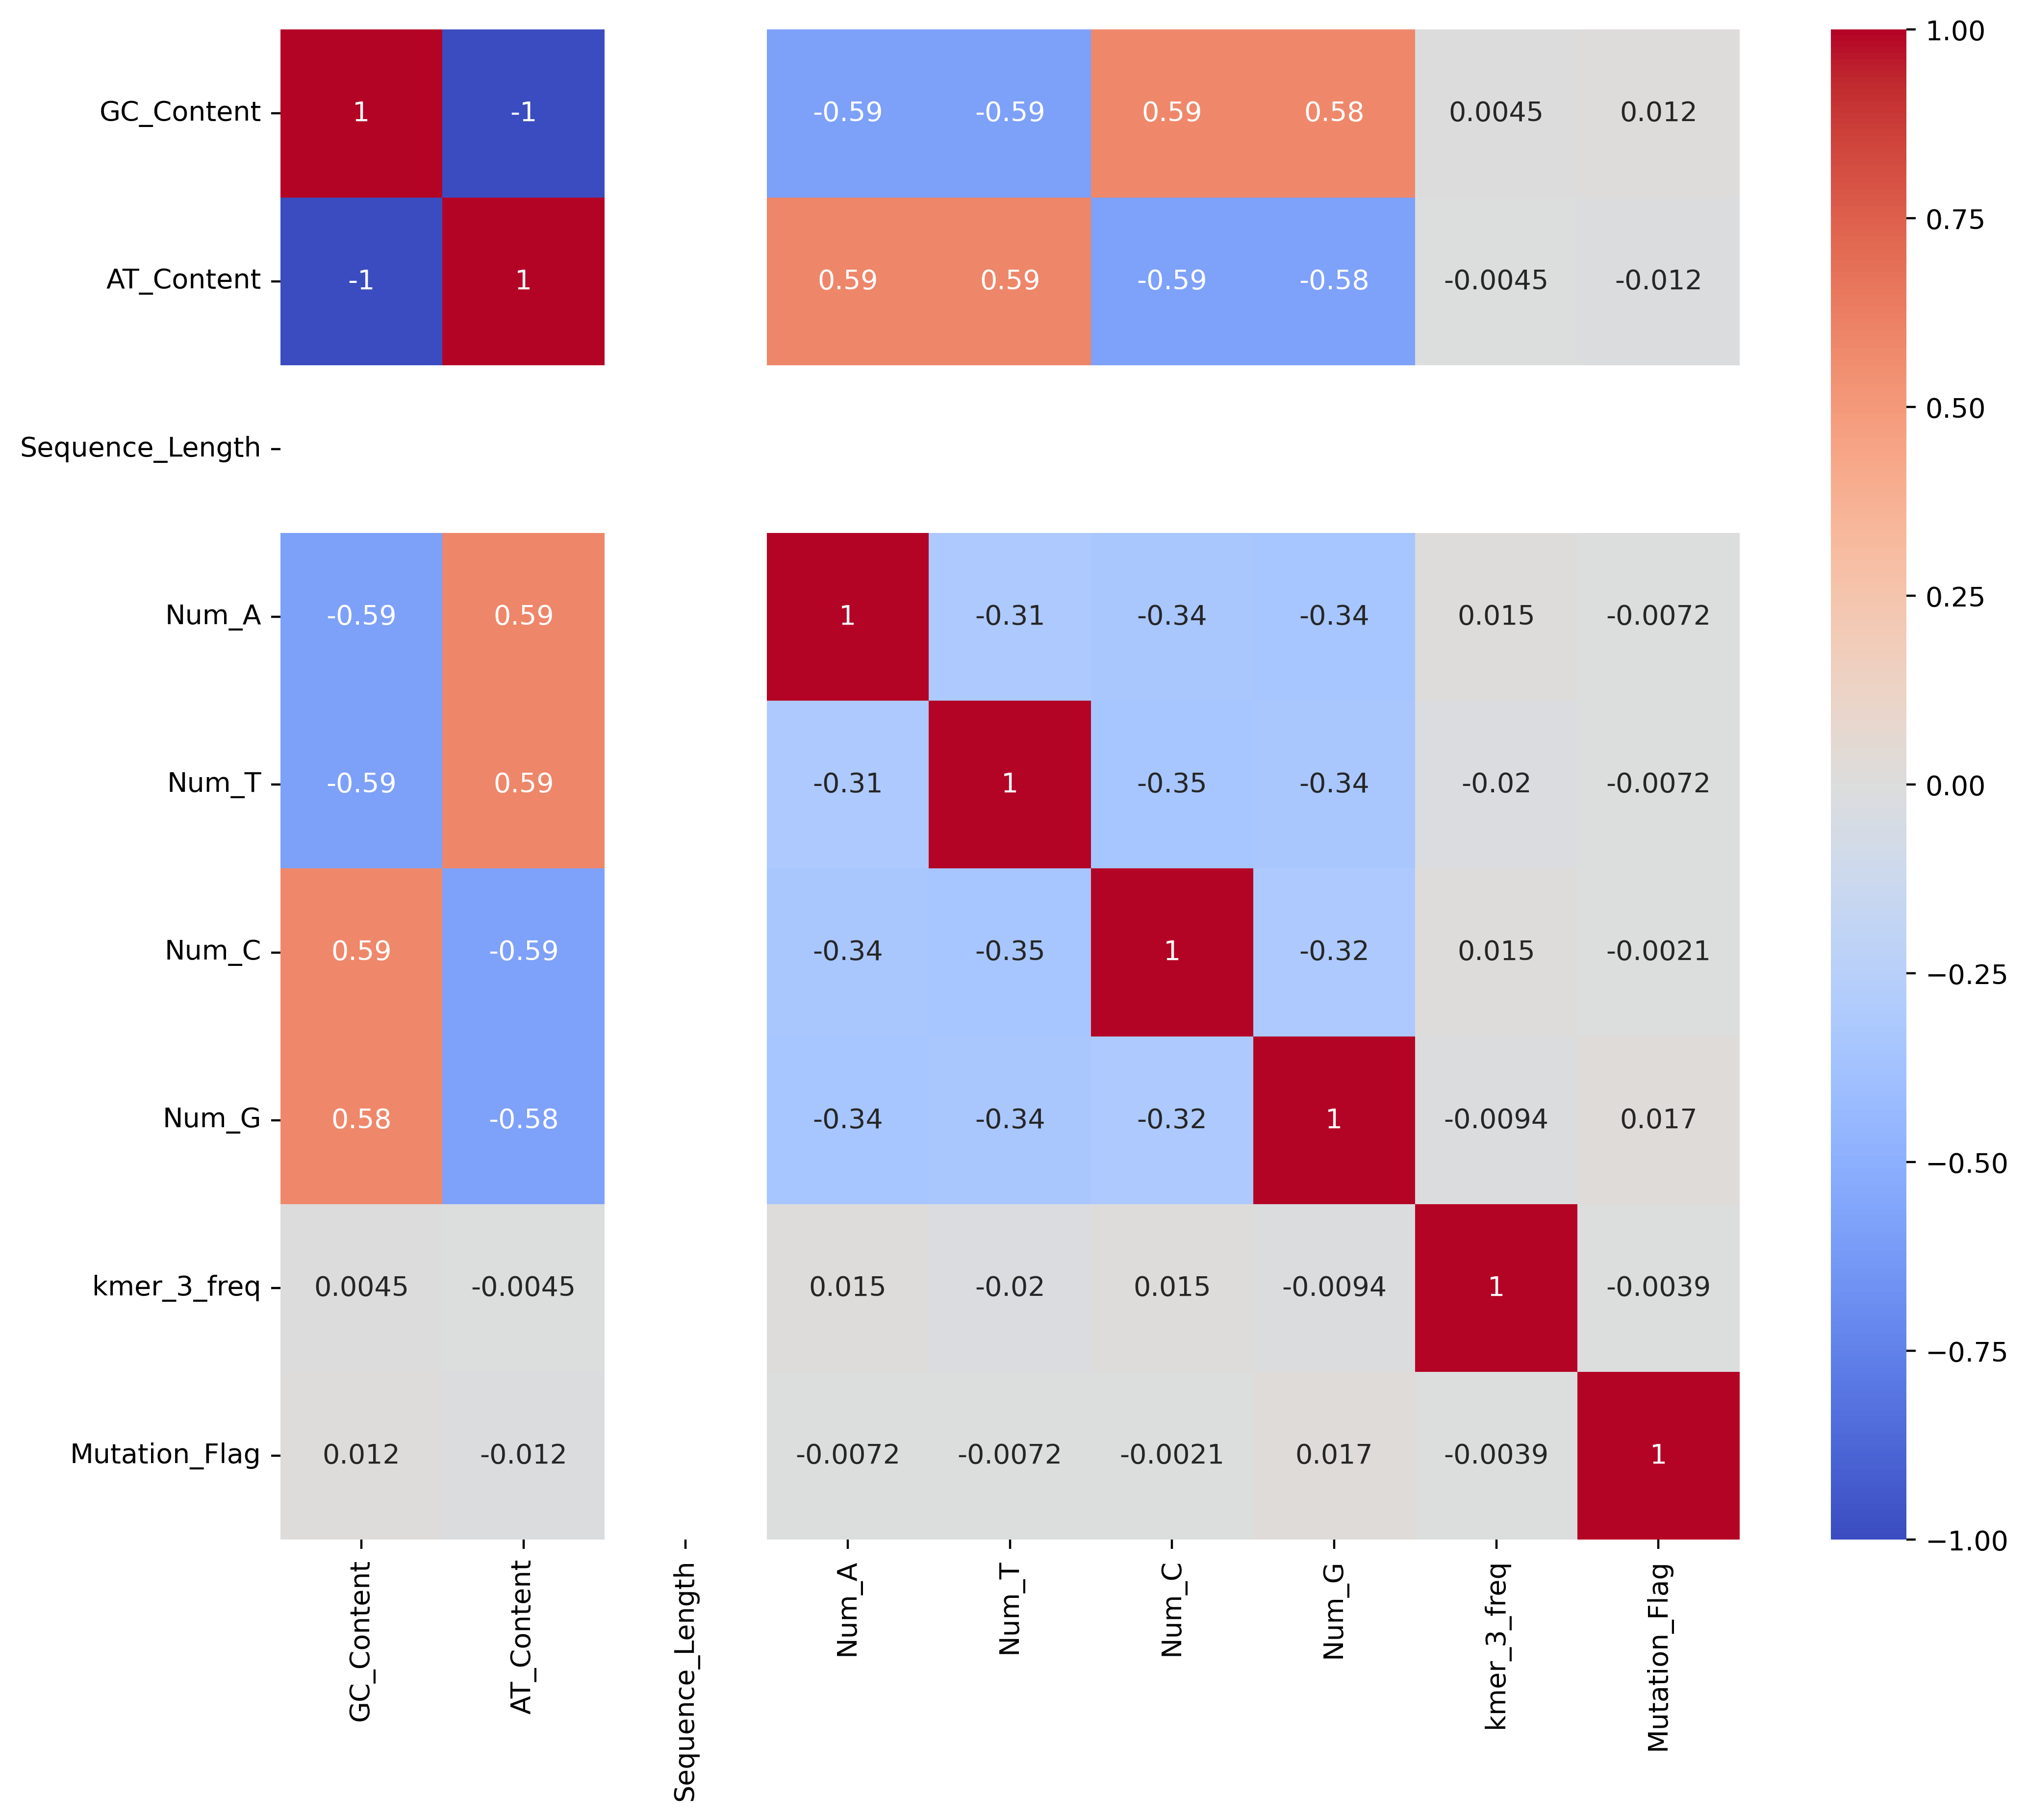

In [6]:
#heatmap für numeric columns
fig, ax = plt.subplots(figsize=(12, 10), dpi=400)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

In [7]:
#Distribution of data by Class_Label and Diese_Risk columns
print(df["Class_Label"].value_counts())
print(df["Disease_Risk"].value_counts())
print(df["Mutation_Flag"].value_counts())

Class_Label
Bacteria    761
Human       749
Plant       747
Virus       743
Name: count, dtype: int64
Disease_Risk
High      1046
Low        978
Medium     976
Name: count, dtype: int64
Mutation_Flag
0    1510
1    1490
Name: count, dtype: int64


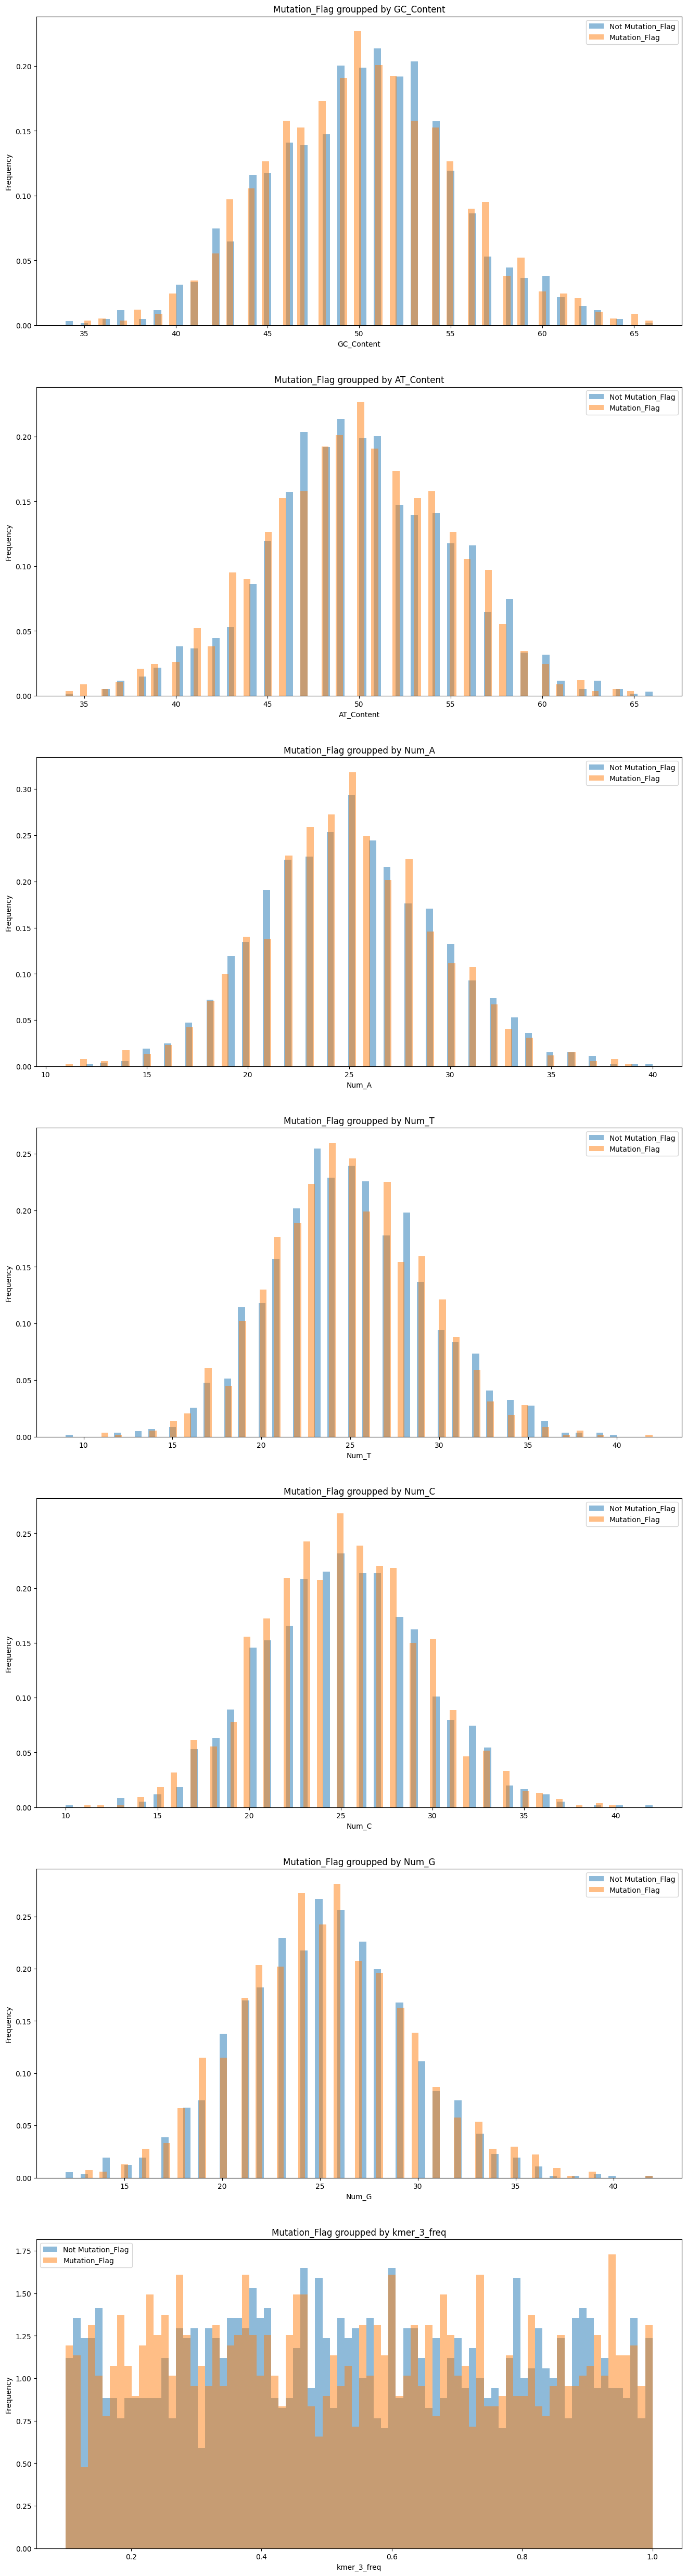

In [8]:
#create numeric columns without sequence_length and mautation_flag columns
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
category_columns = df.select_dtypes(include=['category']).columns.tolist()
selected_numeric_columns = [col for col in numeric_columns if col not in ['Sequence_Length', 'Mutation_Flag']]
#create digrams with Mutation_flag
fig, ax = plt.subplots(nrows=len(selected_numeric_columns), ncols=1, figsize=(16, 5*len(selected_numeric_columns)));
for i, column in enumerate(selected_numeric_columns):
    df.groupby('Mutation_Flag')[column].plot(kind='hist', ax=ax[i], legend=True, alpha=0.5, density=True, bins=80);
    ax[i].set_title(f'Mutation_Flag groupped by {column}');
    ax[i].xaxis.set_tick_params(labelrotation=0);
    ax[i].set_xlabel(column);
    ax[i].legend(['Not Mutation_Flag', 'Mutation_Flag'])
    ax[i].grid(False);
    
plt.suptitle("");
plt.subplots_adjust(top=1.5);
plt.tight_layout;  


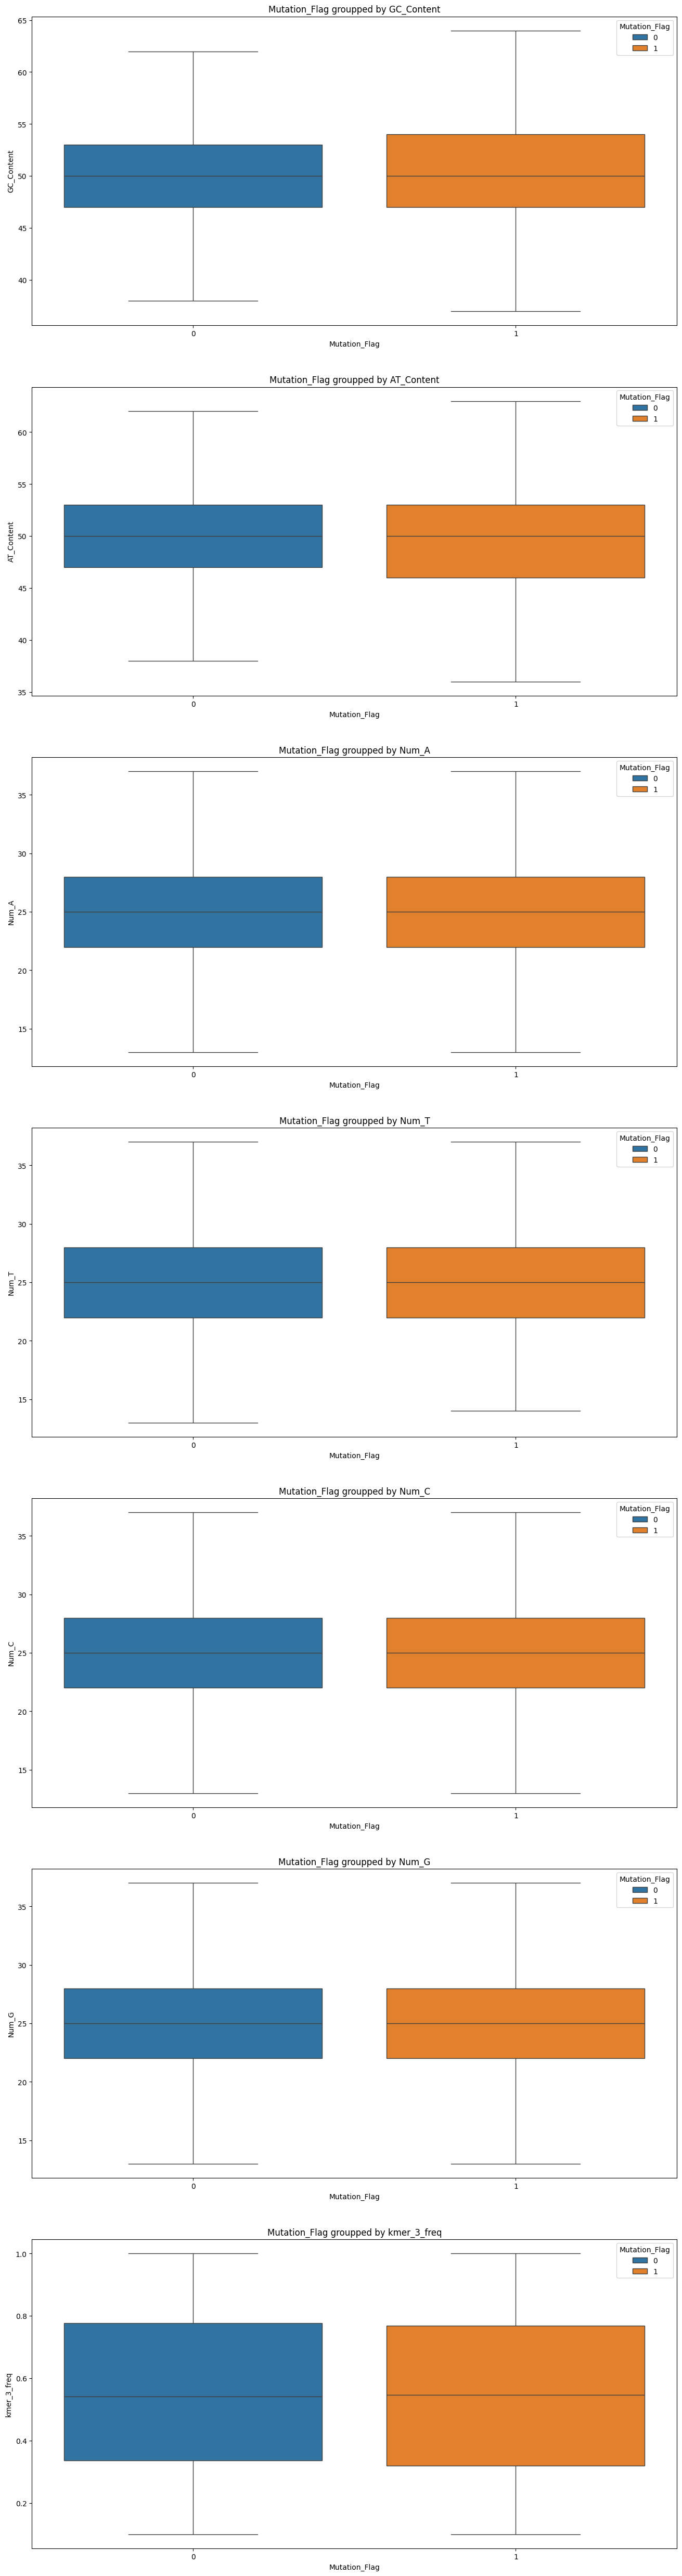

In [9]:


fig, ax = plt.subplots(nrows=len(selected_numeric_columns), ncols=1, figsize=(16, 5*len(selected_numeric_columns)));
for i, column in enumerate(selected_numeric_columns):
    sns.boxplot(x='Mutation_Flag', y=column, data=df, ax=ax[i], showfliers=False, hue='Mutation_Flag')
    ax[i].set_title(f'Mutation_Flag groupped by {column}');
    ax[i].xaxis.set_tick_params(labelrotation=0);
    ax[i].set_xlabel('Mutation_Flag');
    ax[i].grid(False);
    
plt.suptitle("");
plt.subplots_adjust(top=1.5);
plt.tight_layout;  


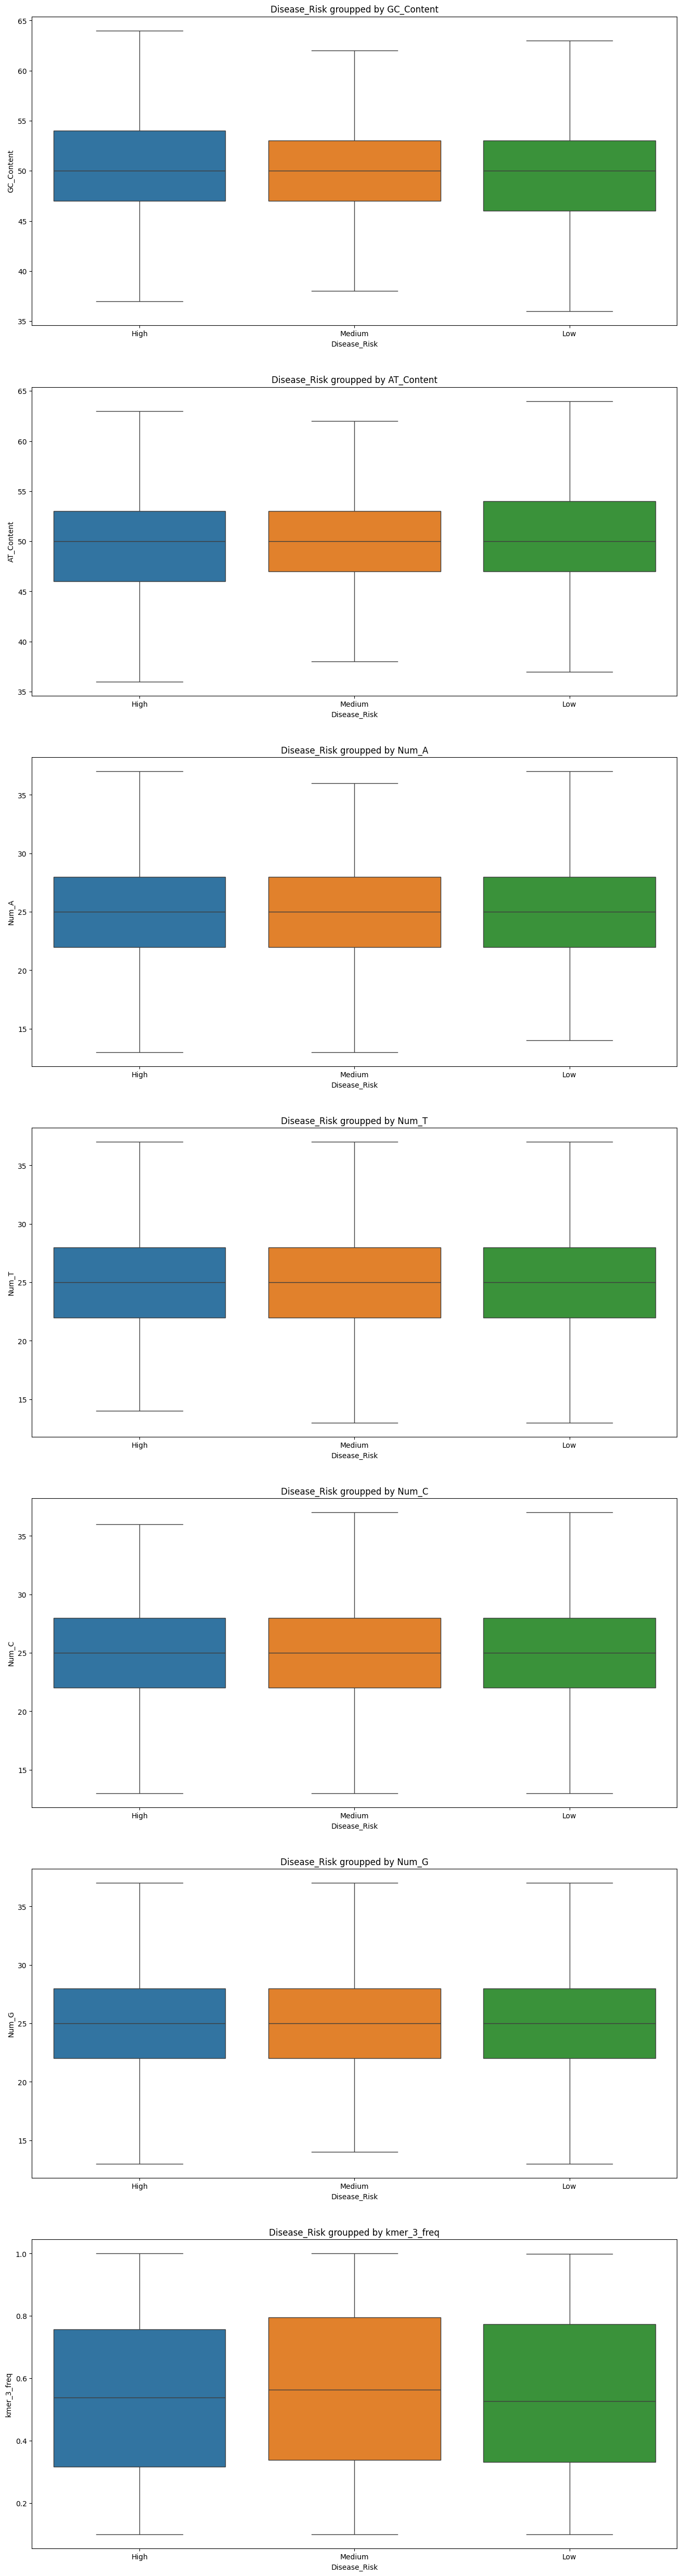

In [10]:
#Visualization of Disease_Risk with numeric columns by histogram
fig, ax = plt.subplots(nrows=len(selected_numeric_columns), ncols=1, figsize=(16, 5*len(selected_numeric_columns)));
for i, column in enumerate(selected_numeric_columns):
    sns.boxplot(x='Disease_Risk', y=column, data=df, ax=ax[i], showfliers=False, hue='Disease_Risk')
    ax[i].set_title(f'Disease_Risk groupped by {column}');
    ax[i].xaxis.set_tick_params(labelrotation=0);
    ax[i].set_xlabel('Disease_Risk');
    ax[i].grid(False);
    
plt.suptitle("");
plt.subplots_adjust(top=1.5);
plt.tight_layout;  


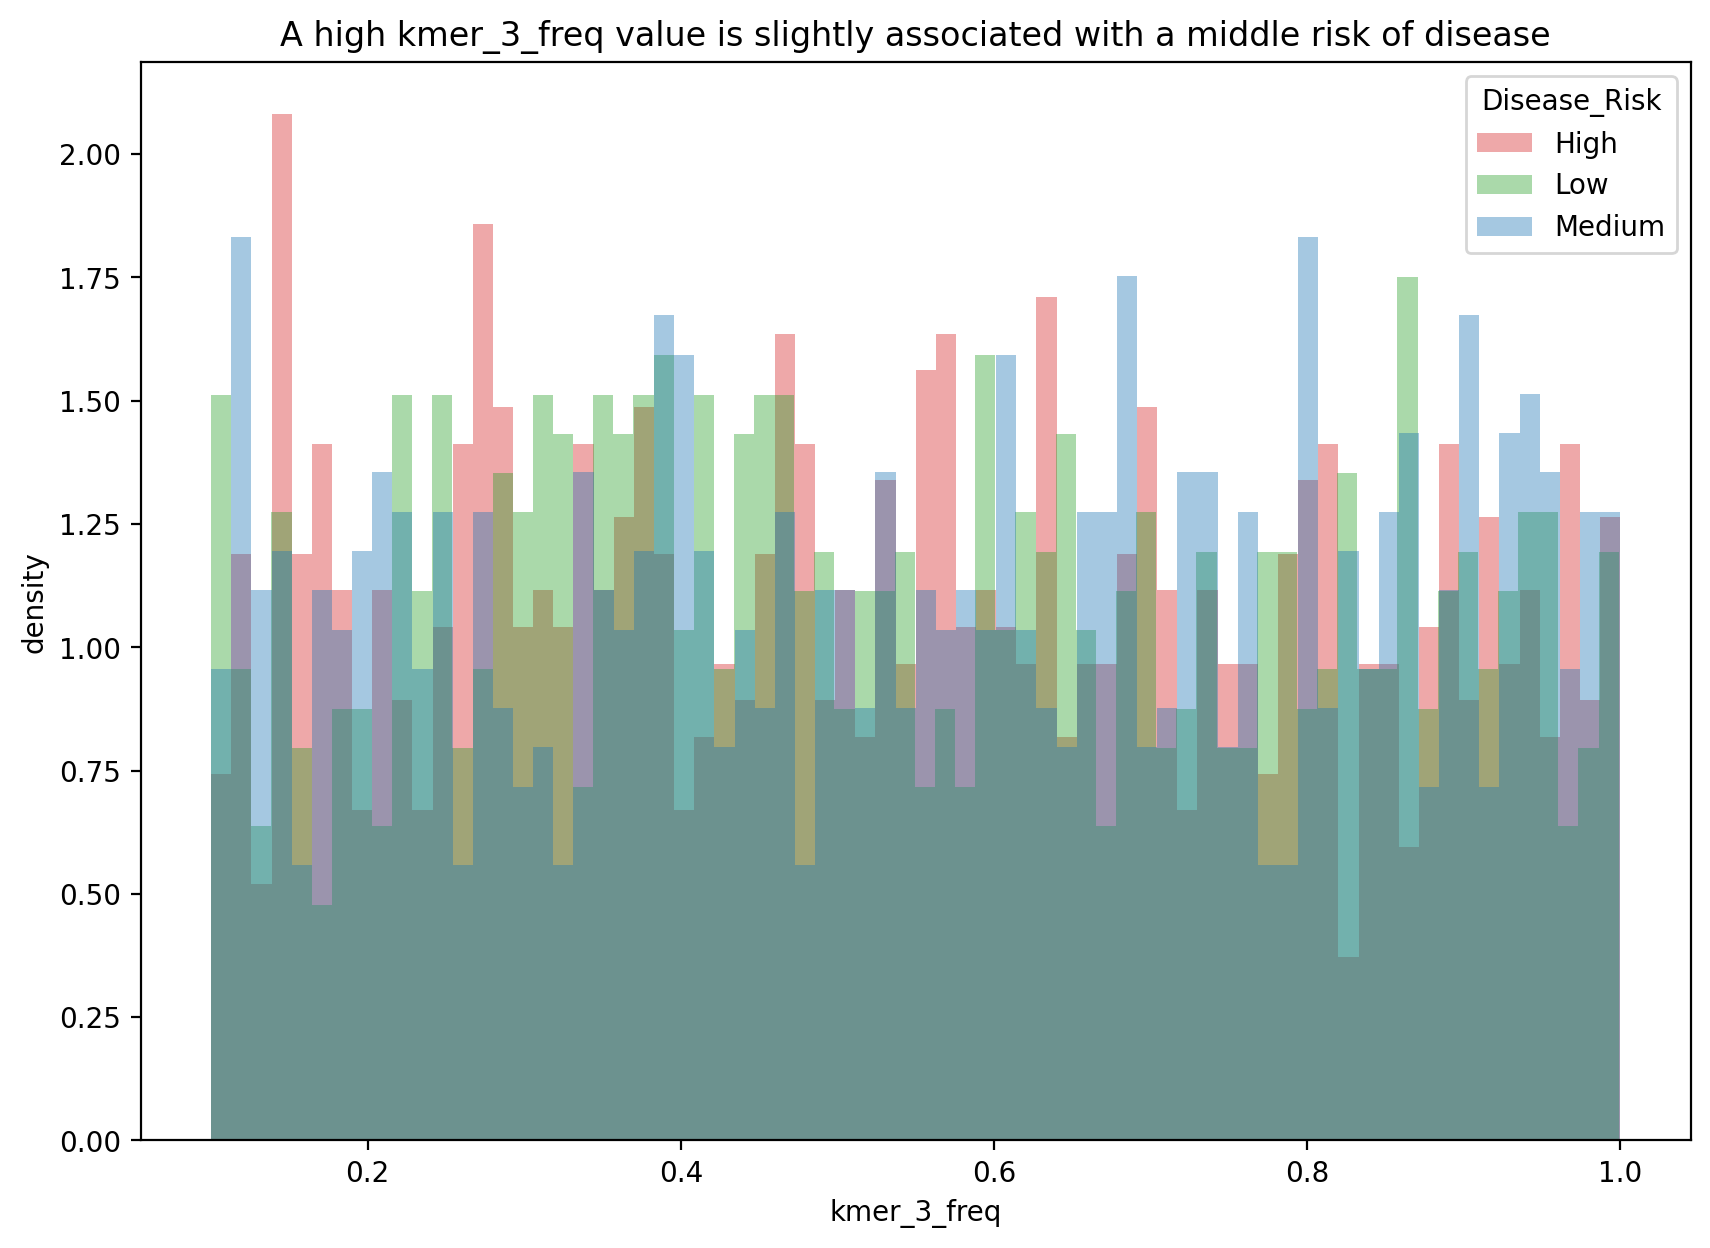

In [11]:
#Visualization of Disease_Risk with numeric columns by histogram
selected_stages = ['High', 'Medium', 'Low']
colors = {'High': 'tab:red', 'Medium': 'tab:blue', 'Low': 'tab:green'}
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
for stage, group in df.groupby('Disease_Risk'):
    if stage in selected_stages:
        group['kmer_3_freq'].plot(
            kind='hist',
            density=True,
            alpha=0.4,
            color=colors[stage],
            ax=ax,
            label=stage, legend=True, bins=70)

ax.set_xlabel('kmer_3_freq')
ax.set_ylabel('density')
ax.set_title('A high kmer_3_freq value is slightly associated with a middle risk of disease')
ax.grid(False);
ax.legend(framealpha=0.005);
plt.legend(title='Disease_Risk')
plt.show()


C:\Users\yamen\AppData\Local\Temp\ipykernel_8360\2141059071.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()]);


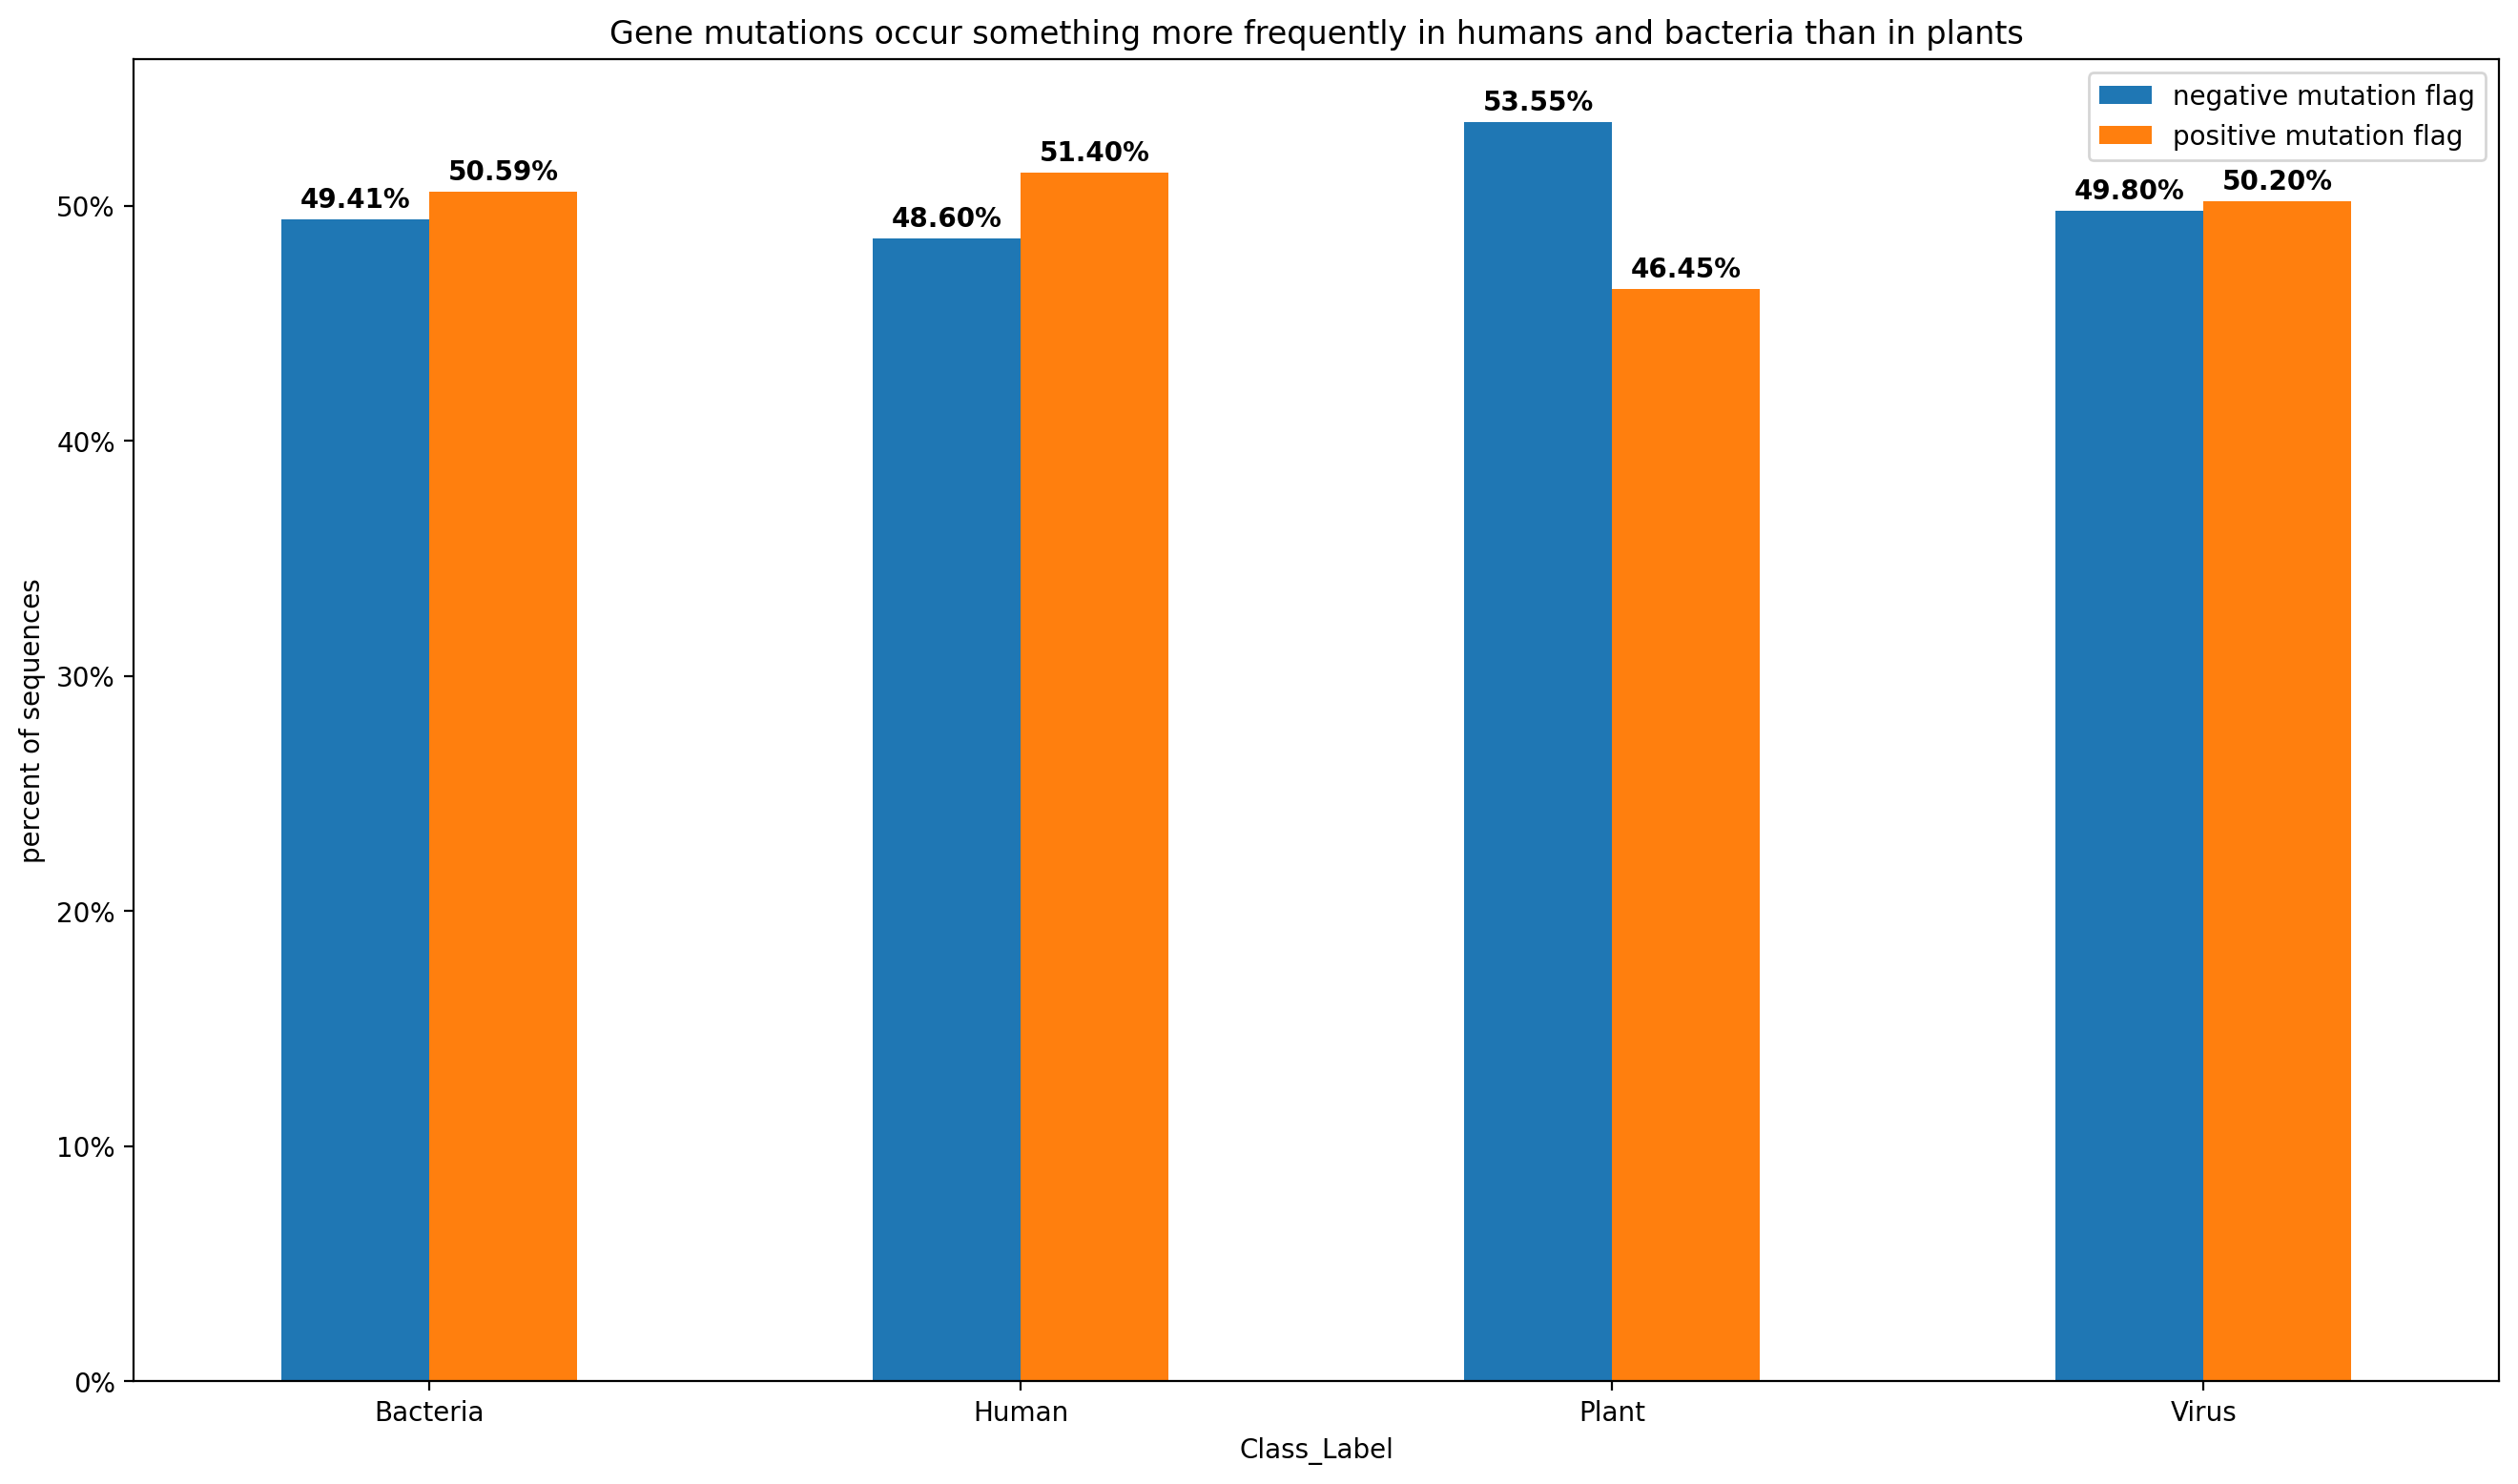

In [12]:
#Visualization of Class_Label with Mutation_flag
fig, ax=plt.subplots(figsize=(16, 9), dpi=200);
pd.crosstab(index=df['Class_Label'], columns=df["Mutation_Flag"], normalize="index").plot(kind="bar", ax=ax, legend=True);
plt.legend(framealpha=0.3);
ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()]); 
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.2%}",
        ha='center',
        fontweight='bold',
        fontsize=10
    );
ax.xaxis.set_tick_params(labelrotation=0);
ax.set(xlabel='Class_Label', ylabel='percent of sequences', title='Gene mutations occur something more frequently in humans and bacteria than in plants');
ax.grid(False);
ax.legend(['negative mutation flag', 'positive mutation flag']);


In [13]:
# calculation of p values
def test_feature(feature):
    g0 = df[df["Mutation_Flag"] == 0][feature]
    g1 = df[df["Mutation_Flag"] == 1][feature]
    _, p = mannwhitneyu(g0, g1)
    return p

for f in ["Num_A", "Num_T", "Num_C", "Num_G", "kmer_3_freq"]:
    print(f, "p-value:", test_feature(f))


Num_A p-value: 0.9411371286484143
Num_T p-value: 0.8310530887063706
Num_C p-value: 0.9485811189184049
Num_G p-value: 0.6206530426382963
kmer_3_freq p-value: 0.8147752662028044


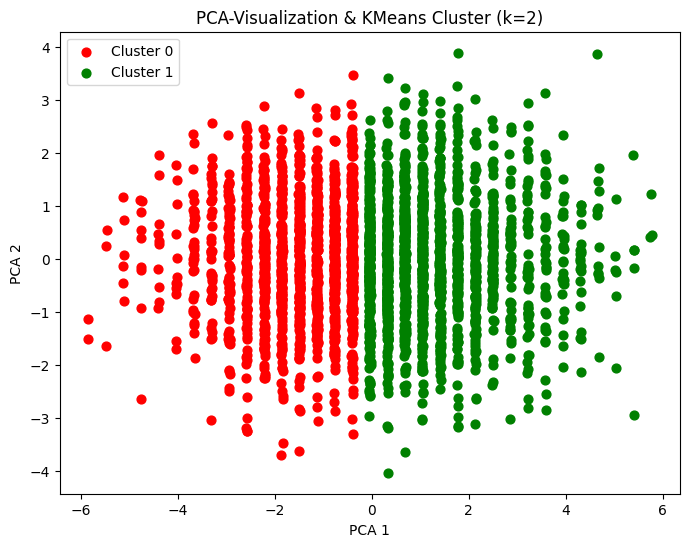

In [14]:
#clustering visualization
#Preprocessing: One-Hot + Scaling
ct = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), category_columns),
    ("scale", StandardScaler(), numeric_columns)
])
X = ct.fit_transform(df)
#PCA für better clustering
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)
#KMeans Clustering (k = 2)
k = 2
model = KMeans(n_clusters=k, random_state=42)
clusters = model.fit_predict(X_pca)
df["cluster"] = clusters
#PCA on 2D for visualization
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X_pca)
colors = ['red', 'green']
fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id, color in enumerate(colors):
    ax.scatter(
        coords[df["cluster"] == cluster_id, 0], 
        coords[df["cluster"] == cluster_id, 1],
        s=40,
        color=color,
        label=f"Cluster {cluster_id}")

ax.set_title("PCA-Visualization & KMeans Cluster (k=2)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend();
ax.grid(False);

In [15]:
#clustering Datafram
summary = df.groupby("cluster").mean(numeric_only=True)
#summary = summary[['diagnosed_diabetes'] + [c for c in summary.columns if c != 'diagnosed_diabetes']]
print("Cluster Datafran (numerische mean):")
display(summary)

Cluster Datafran (numerische mean):


,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag
cluster,,,,,,,,,
0,45.61203,54.38797,100.0,27.180451,27.207519,22.693985,22.918045,0.545308,0.499248
1,53.71018,46.28982,100.0,23.174850,23.114970,26.843713,26.866467,0.549674,0.494611


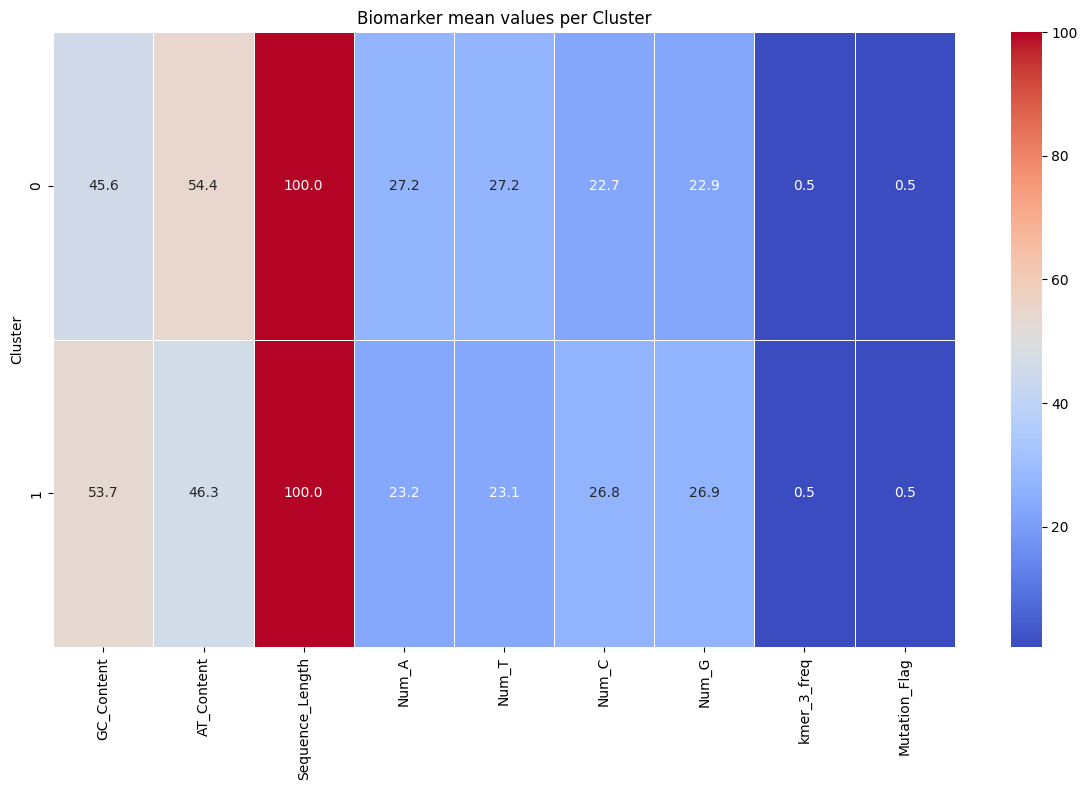

In [16]:
#heatmap by clustering
features = df.select_dtypes(include=['number']).columns
clustered_df = df[features].copy()

# Cluster-Mittelwerte berechnen
cluster_means = clustered_df.groupby(df["cluster"]).mean()
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means.drop(columns=['cluster']),
            cmap="coolwarm",
            annot=True,
            fmt=".1f",
            linewidths=0.5)

plt.title("Biomarker mean values per Cluster")
plt.ylabel("Cluster")
plt.tight_layout()

In [17]:
#Nukleotid Frequencies
def nucleotide_frequencies(seq):
    counts = Counter(seq)
    total = len(seq)
    return {
        "A_freq": counts.get("A", 0) / total,
        "T_freq": counts.get("T", 0) / total,
        "C_freq": counts.get("C", 0) / total,
        "G_freq": counts.get("G", 0) / total,
    }

nuc_freqs = df["Sequence"].apply(nucleotide_frequencies).apply(pd.Series)
df = pd.concat([df, nuc_freqs], axis=1)
df

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk,cluster,A_freq,T_freq,C_freq,G_freq
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,100,22,28,19,31,0.986,0,Bacteria,High,1,0.22,0.28,0.19,0.31
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,100,27,28,22,23,0.486,1,Virus,Medium,0,0.27,0.28,0.22,0.23
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,100,26,23,30,21,0.367,1,Bacteria,Low,1,0.26,0.23,0.30,0.21
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,100,28,17,23,32,0.404,0,Human,Medium,1,0.28,0.17,0.23,0.32
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,100,24,30,25,21,0.818,0,Human,High,0,0.24,0.30,0.25,0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,SAMPLE_2996,GATCAGCCCATACACCAAATCAATTGCATACATGTCCGATGTAACA...,46.0,54.0,100,30,24,27,19,0.786,1,Plant,Medium,0,0.30,0.24,0.27,0.19
2996,SAMPLE_2997,TGTTGTGTGTCTGATGATAGGTCATACCGCCTCGAAACATCACCAT...,49.0,51.0,100,28,23,24,25,0.831,0,Plant,Medium,0,0.28,0.23,0.24,0.25
2997,SAMPLE_2998,GACCCACTAAAAGTCTTCGTCTCCTTCCGATGGGAATTTTCGCCGA...,53.0,47.0,100,21,26,30,23,0.140,0,Virus,Medium,1,0.21,0.26,0.30,0.23
2998,SAMPLE_2999,CCAAAGGATATCTGTAATTGTTGCAGCGCCCCTACAATTTGAGCAC...,46.0,54.0,100,26,28,25,21,0.685,0,Plant,Medium,0,0.26,0.28,0.25,0.21


In [18]:
#calculation of kmer_3_mean_freq
def kmer_frequency(seq, k=3):
    kmers = [seq[i:i+k] for i in range(len(seq)-k+1)]
    counts = Counter(kmers)
    return np.mean(list(counts.values()))

df["kmer_3_mean_freq"] = df["Sequence"].apply(kmer_frequency)
df

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk,cluster,A_freq,T_freq,C_freq,G_freq,kmer_3_mean_freq
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,100,22,28,19,31,0.986,0,Bacteria,High,1,0.22,0.28,0.19,0.31,1.960000
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,100,27,28,22,23,0.486,1,Virus,Medium,0,0.27,0.28,0.22,0.23,1.750000
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,100,26,23,30,21,0.367,1,Bacteria,Low,1,0.26,0.23,0.30,0.21,1.884615
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,100,28,17,23,32,0.404,0,Human,Medium,1,0.28,0.17,0.23,0.32,2.000000
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,100,24,30,25,21,0.818,0,Human,High,0,0.24,0.30,0.25,0.21,1.849057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,SAMPLE_2996,GATCAGCCCATACACCAAATCAATTGCATACATGTCCGATGTAACA...,46.0,54.0,100,30,24,27,19,0.786,1,Plant,Medium,0,0.30,0.24,0.27,0.19,1.884615
2996,SAMPLE_2997,TGTTGTGTGTCTGATGATAGGTCATACCGCCTCGAAACATCACCAT...,49.0,51.0,100,28,23,24,25,0.831,0,Plant,Medium,0,0.28,0.23,0.24,0.25,1.884615
2997,SAMPLE_2998,GACCCACTAAAAGTCTTCGTCTCCTTCCGATGGGAATTTTCGCCGA...,53.0,47.0,100,21,26,30,23,0.140,0,Virus,Medium,1,0.21,0.26,0.30,0.23,1.960000
2998,SAMPLE_2999,CCAAAGGATATCTGTAATTGTTGCAGCGCCCCTACAATTTGAGCAC...,46.0,54.0,100,26,28,25,21,0.685,0,Plant,Medium,0,0.26,0.28,0.25,0.21,1.750000


In [19]:
#Sequenz-Entropie
def sequence_entropy(seq):
    counts = Counter(seq)
    probs = np.array(list(counts.values())) / len(seq)
    return -np.sum(probs * np.log2(probs))

df["Sequence_Entropy"] = df["Sequence"].apply(sequence_entropy)
df

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk,cluster,A_freq,T_freq,C_freq,G_freq,kmer_3_mean_freq,Sequence_Entropy
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,100,22,28,19,31,0.986,0,Bacteria,High,1,0.22,0.28,0.19,0.31,1.960000,1.973815
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,100,27,28,22,23,0.486,1,Virus,Medium,0,0.27,0.28,0.22,0.23,1.750000,1.992483
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,100,26,23,30,21,0.367,1,Bacteria,Low,1,0.26,0.23,0.30,0.21,1.884615,1.986869
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,100,28,17,23,32,0.404,0,Human,Medium,1,0.28,0.17,0.23,0.32,2.000000,1.962509
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,100,24,30,25,21,0.818,0,Human,High,0,0.24,0.30,0.25,0.21,1.849057,1.988047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,SAMPLE_2996,GATCAGCCCATACACCAAATCAATTGCATACATGTCCGATGTAACA...,46.0,54.0,100,30,24,27,19,0.786,1,Plant,Medium,0,0.30,0.24,0.27,0.19,1.884615,1.980472
2996,SAMPLE_2997,TGTTGTGTGTCTGATGATAGGTCATACCGCCTCGAAACATCACCAT...,49.0,51.0,100,28,23,24,25,0.831,0,Plant,Medium,0,0.28,0.23,0.24,0.25,1.884615,1.996023
2997,SAMPLE_2998,GACCCACTAAAAGTCTTCGTCTCCTTCCGATGGGAATTTTCGCCGA...,53.0,47.0,100,21,26,30,23,0.140,0,Virus,Medium,1,0.21,0.26,0.30,0.23,1.960000,1.986869
2998,SAMPLE_2999,CCAAAGGATATCTGTAATTGTTGCAGCGCCCCTACAATTTGAGCAC...,46.0,54.0,100,26,28,25,21,0.685,0,Plant,Medium,0,0.26,0.28,0.25,0.21,1.750000,1.992332


In [20]:
#encoding of Class_Label and Disease_Risk columns
le_class = LabelEncoder()
le_risk = LabelEncoder()

df["Class_Label_enc"] = le_class.fit_transform(df["Class_Label"])
df["Disease_Risk_enc"] = le_risk.fit_transform(df["Disease_Risk"])
df

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,...,Disease_Risk,cluster,A_freq,T_freq,C_freq,G_freq,kmer_3_mean_freq,Sequence_Entropy,Class_Label_enc,Disease_Risk_enc
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,100,22,28,19,31,0.986,...,High,1,0.22,0.28,0.19,0.31,1.960000,1.973815,0,0
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,100,27,28,22,23,0.486,...,Medium,0,0.27,0.28,0.22,0.23,1.750000,1.992483,3,2
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,100,26,23,30,21,0.367,...,Low,1,0.26,0.23,0.30,0.21,1.884615,1.986869,0,1
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,100,28,17,23,32,0.404,...,Medium,1,0.28,0.17,0.23,0.32,2.000000,1.962509,1,2
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,100,24,30,25,21,0.818,...,High,0,0.24,0.30,0.25,0.21,1.849057,1.988047,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,SAMPLE_2996,GATCAGCCCATACACCAAATCAATTGCATACATGTCCGATGTAACA...,46.0,54.0,100,30,24,27,19,0.786,...,Medium,0,0.30,0.24,0.27,0.19,1.884615,1.980472,2,2
2996,SAMPLE_2997,TGTTGTGTGTCTGATGATAGGTCATACCGCCTCGAAACATCACCAT...,49.0,51.0,100,28,23,24,25,0.831,...,Medium,0,0.28,0.23,0.24,0.25,1.884615,1.996023,2,2
2997,SAMPLE_2998,GACCCACTAAAAGTCTTCGTCTCCTTCCGATGGGAATTTTCGCCGA...,53.0,47.0,100,21,26,30,23,0.140,...,Medium,1,0.21,0.26,0.30,0.23,1.960000,1.986869,3,2
2998,SAMPLE_2999,CCAAAGGATATCTGTAATTGTTGCAGCGCCCCTACAATTTGAGCAC...,46.0,54.0,100,26,28,25,21,0.685,...,Medium,0,0.26,0.28,0.25,0.21,1.750000,1.992332,2,2


In [21]:
#Randomforest by machine learning
feature_cols = [
    "GC_Content",
    "Mutation_Flag",
    "kmer_3_freq",
    "kmer_3_mean_freq",
    "Sequence_Entropy",
    "A_freq", "T_freq", "C_freq", "G_freq"
]

X = df[feature_cols]
y = df["Class_Label_enc"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le_class.classes_))

              precision    recall  f1-score   support

    Bacteria       0.26      0.26      0.26       190
       Human       0.30      0.30      0.30       187
       Plant       0.25      0.26      0.26       187
       Virus       0.27      0.25      0.26       186

    accuracy                           0.27       750
   macro avg       0.27      0.27      0.27       750
weighted avg       0.27      0.27      0.27       750



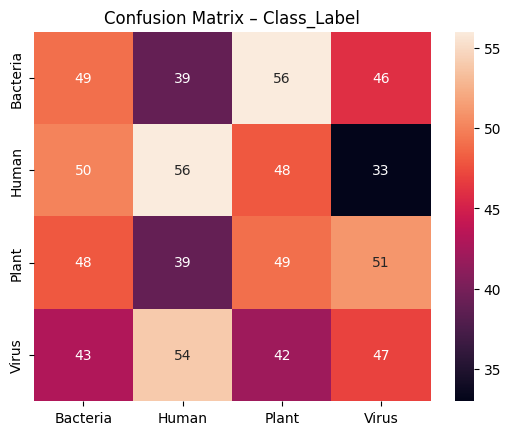

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le_class.classes_,
            yticklabels=le_class.classes_)
plt.title("Confusion Matrix – Class_Label")
plt.show()

In [23]:
cm.sum(axis=0)

array([190, 188, 195, 177])

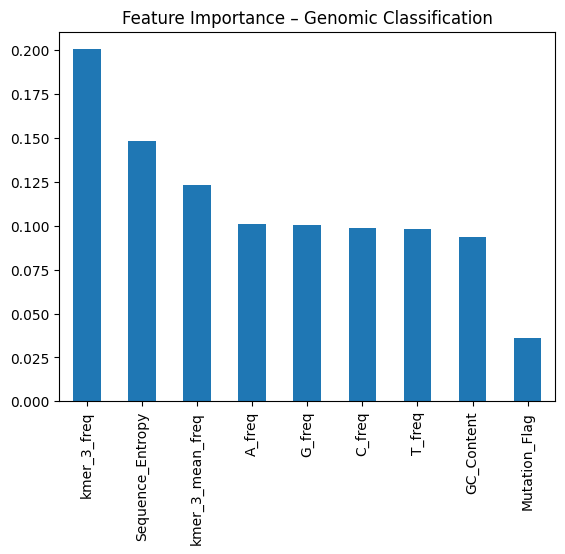

In [24]:
#feature importance
importances = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importances.plot(kind="bar")
plt.title("Feature Importance – Genomic Classification")
plt.show()